In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from targetree import targetree
from targetree.tree_vis import plot_cart_tree
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
EXAMPLES_DIR = PROJECT_ROOT / "examples"
DATA_DIR = EXAMPLES_DIR / "data"
FIGURE_DIR = EXAMPLES_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

### 1. diabetes

In [23]:
df_diabetes = pd.read_csv(DATA_DIR / "diabetes.csv")

In [24]:
y1 = np.array(df_diabetes['Outcome'])
X1 = np.array(df_diabetes.drop(['Outcome'],axis=1))

In [25]:
cut = 0.4
max_depth = 3
mp = 30/df_diabetes.shape[0]
fs = 15  # automatically use the largest uniform font that fits
split_lines = 2  # put the feature name and condition on separate lines

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 30.9500]
      Leaf: mean=0.013, n=151
      Leaf: mean=0.175, n=120
    [BMI <= 26.3500]
      Leaf: mean=0.049, n=41
      Leaf: mean=0.399, n=173
  [BMI <= 29.9500]
    [Glucose <= 145.5000]
      Leaf: mean=0.146, n=41
      Leaf: mean=0.514, n=35
    [Glucose <= 157.5000]
      Leaf: mean=0.609, n=115
      Leaf: mean=0.870, n=92


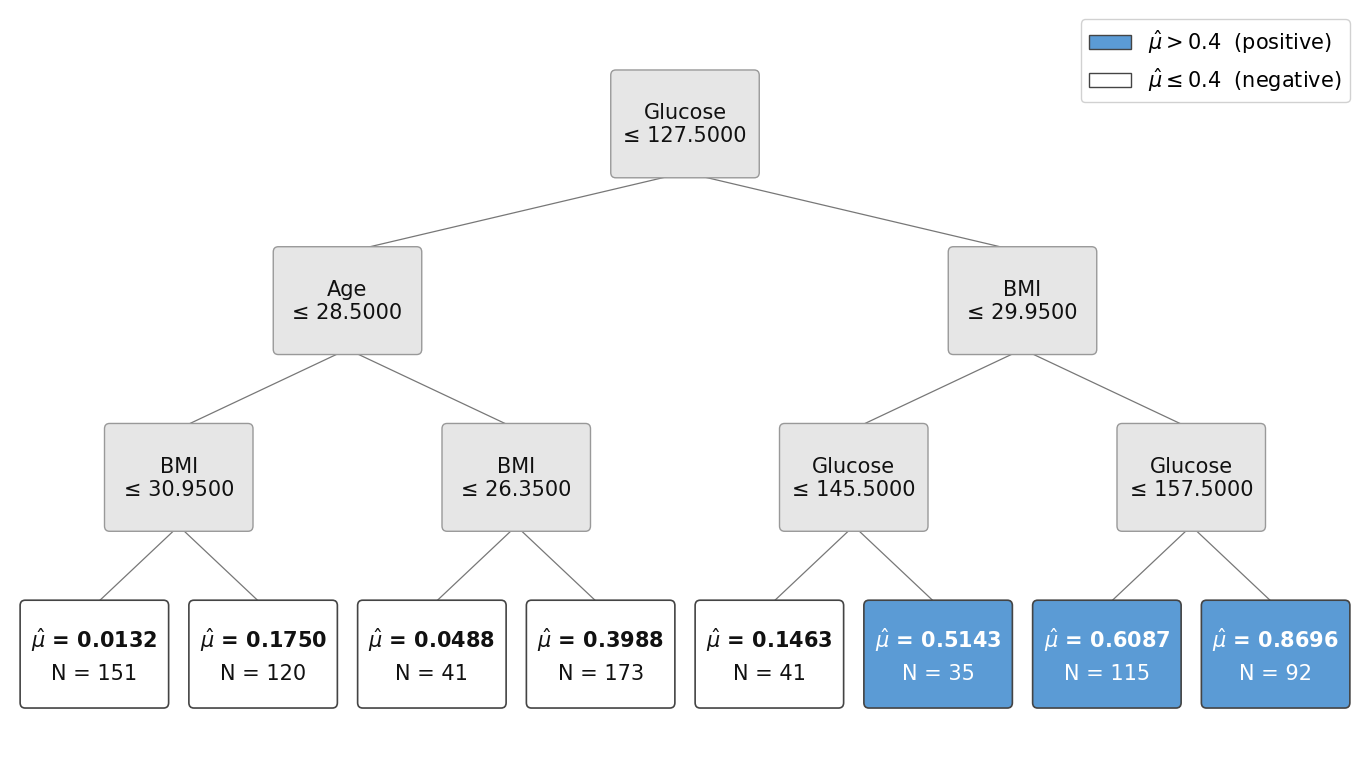

In [26]:
###### cart ######
model = targetree(depth=max_depth, minimum_portion=mp, lbd=0, cut=cut, method = 'cart',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "diabetes_cart.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 22.7500]
      Leaf: mean=0.000, n=41
      Leaf: mean=0.100, n=230
    [BMI <= 38.9500]
      Leaf: mean=0.311, n=183
      Leaf: mean=0.452, n=31
  [BMI <= 29.9500]
    [Glucose <= 145.5000]
      Leaf: mean=0.146, n=41
      Leaf: mean=0.514, n=35
    [Glucose <= 145.5000]
      Leaf: mean=0.641, n=78
      Leaf: mean=0.775, n=129


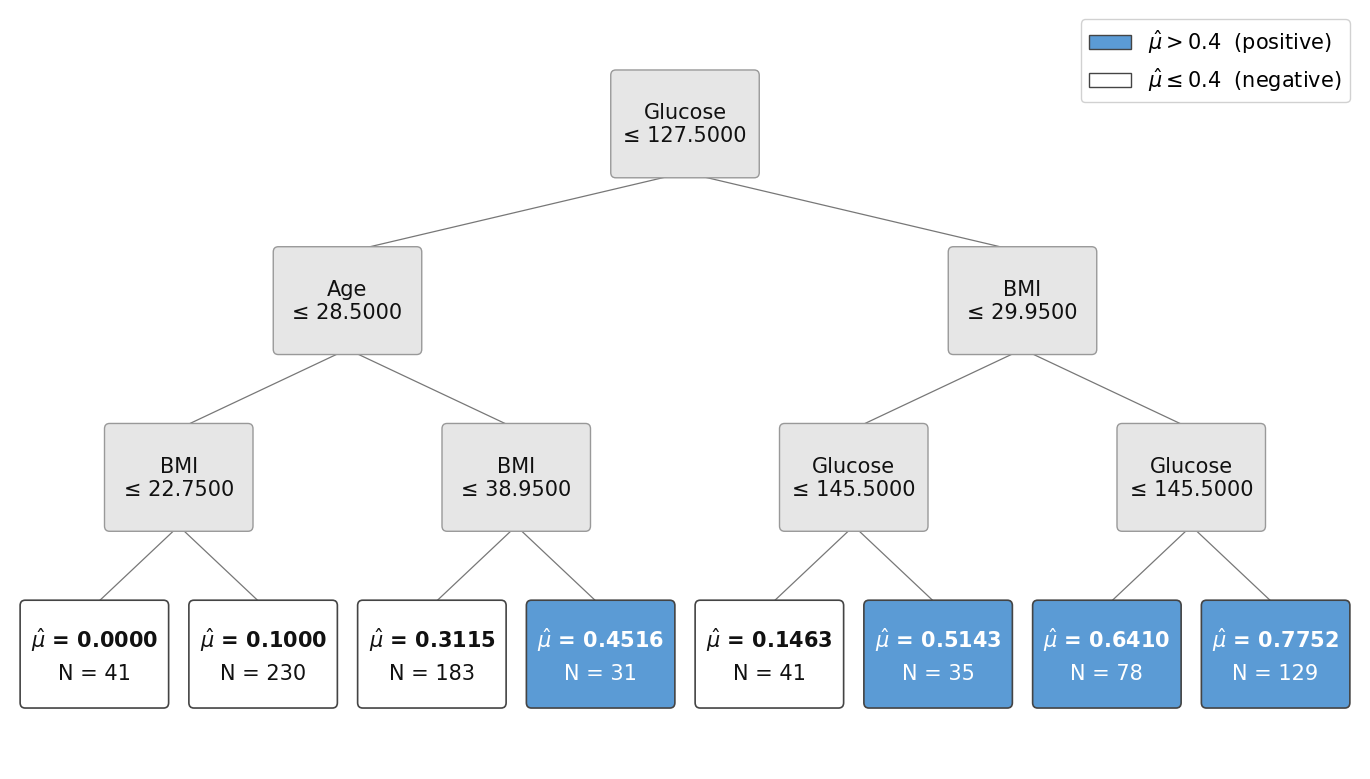

In [27]:
# mdfs
model = targetree(depth=max_depth, minimum_portion=mp, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "diabetes_mdfs.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 30.9500]
      Leaf: mean=0.013, n=151
      Leaf: mean=0.175, n=120
    [BMI <= 26.9500]
      Leaf: mean=0.067, n=45
      Leaf: mean=0.402, n=169
  [BMI <= 29.9500]
    [Glucose <= 145.5000]
      Leaf: mean=0.146, n=41
      Leaf: mean=0.514, n=35
    [Glucose <= 157.5000]
      Leaf: mean=0.609, n=115
      Leaf: mean=0.870, n=92


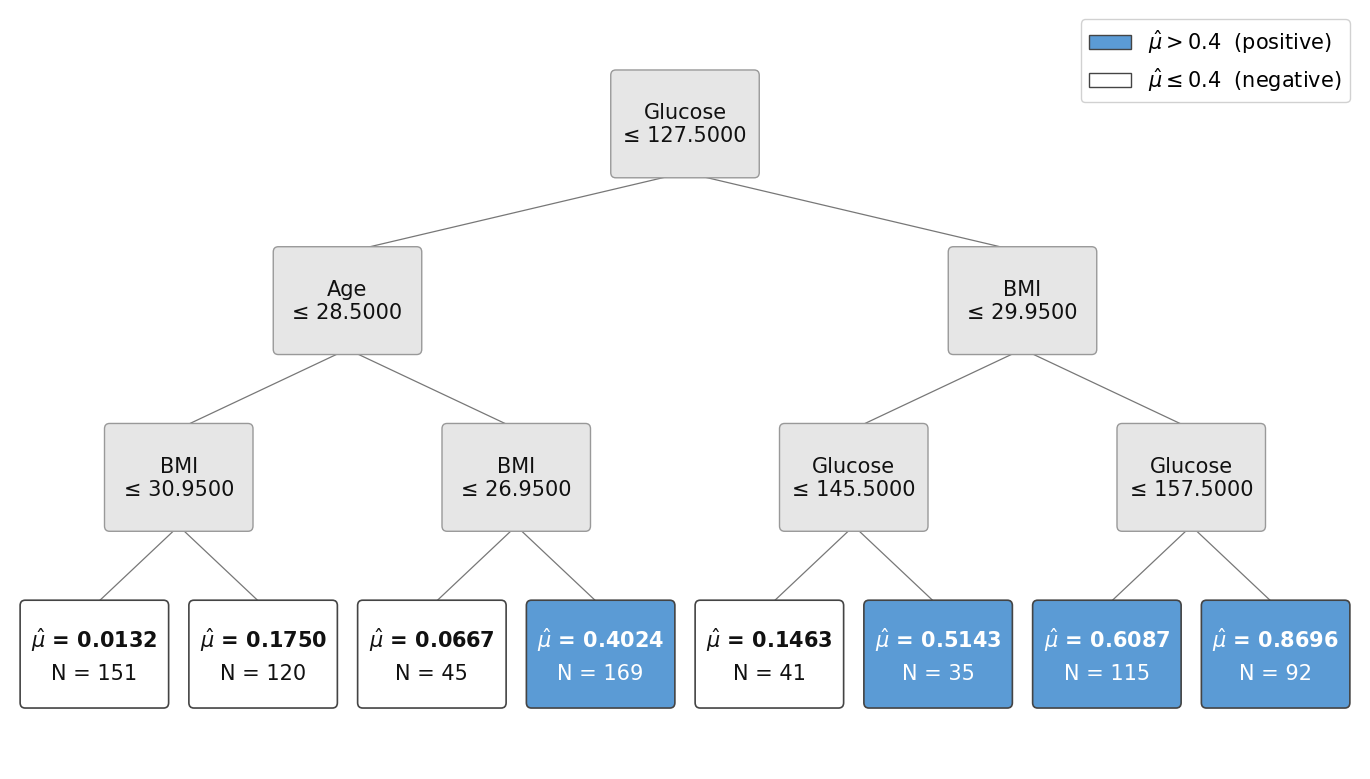

In [28]:
# pfs
model = targetree(depth=max_depth, minimum_portion=mp, lbd=0.5, cut=cut, method = 'pfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "diabetes_pfs.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()

### 2. forestfires

In [29]:
df_forestfires = pd.read_csv(DATA_DIR / "forestfires.csv")
df_forestfires['month_num'] = df_forestfires['month'].map(
    {'jan': 1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9,'oct':10,'nov':11,'dec':12})

In [30]:
y1 = np.array(1*(df_forestfires['area']>5))
X1 = np.array(df_forestfires.drop(['month', 'day','area','month_num'],axis=1))

In [31]:
df_forestfires_ = df_forestfires.drop(['month', 'day','area','month_num'],axis=1)

In [32]:
cut = 0.35
max_depth = 3
mp = 30/df_forestfires_.shape[0]

In [33]:
# df_forestfires_

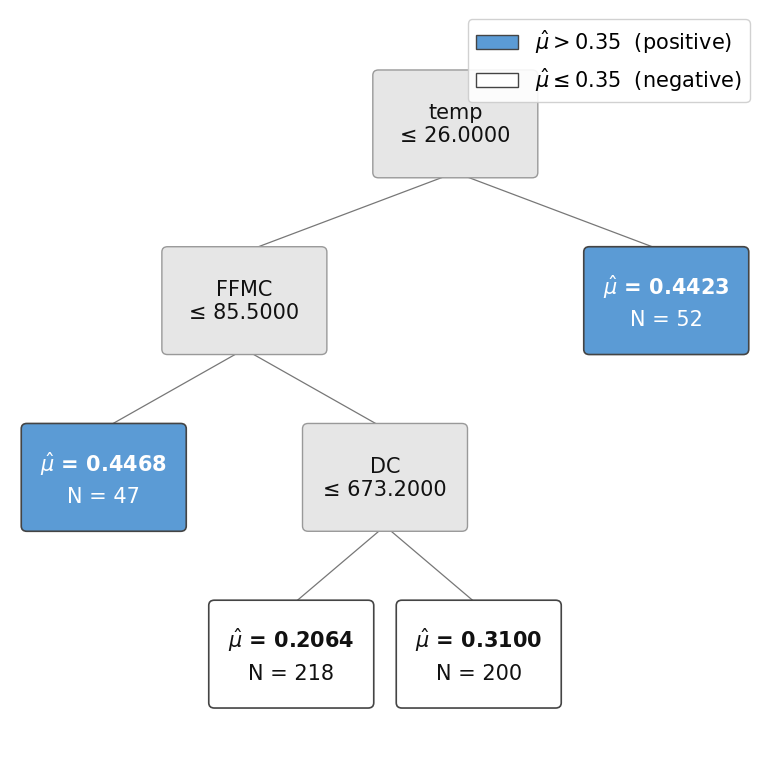

In [34]:
###### cart ######
model = targetree(depth=max_depth, minimum_portion= mp, cut=cut, method = 'cart',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "forestfires_cart.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()


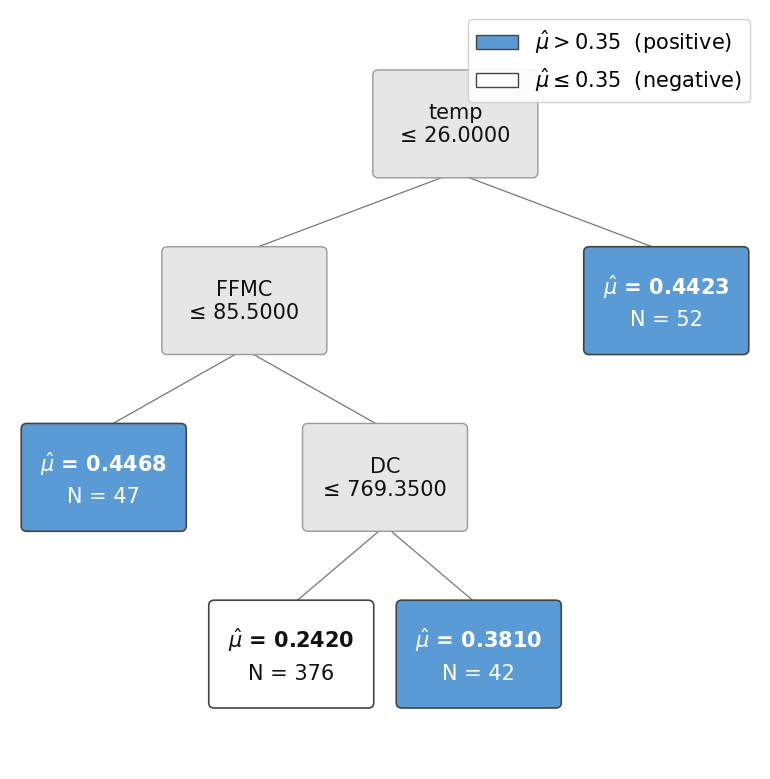

In [35]:
# mdfs
model = targetree(depth=max_depth, minimum_portion=mp, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "forestfires_mdfs.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()

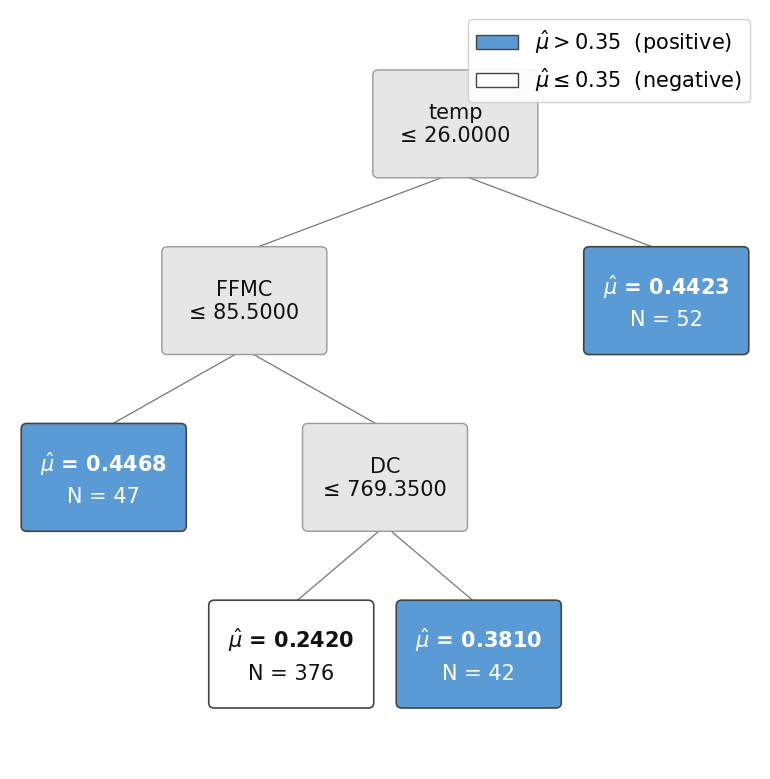

In [36]:
# pfs
model = targetree(depth=max_depth, minimum_portion=mp, lbd=0.5, cut=cut, method = 'pfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "forestfires_pfs.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()

In [37]:
cut = 0.333
max_depth = 3

In [38]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X1, y1)
phat = rf.predict_proba(X1)[:,1]

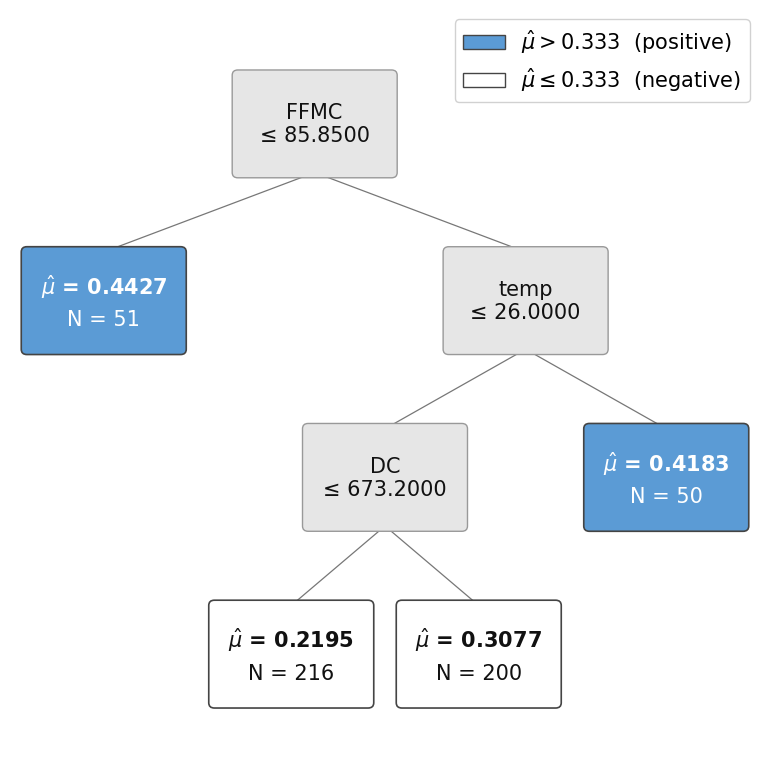

In [39]:
###### cart ######
model = targetree(depth=max_depth, minimum_portion=mp,cut=cut, method = 'cart',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1, phat)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "forestfires_phat_cart.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()

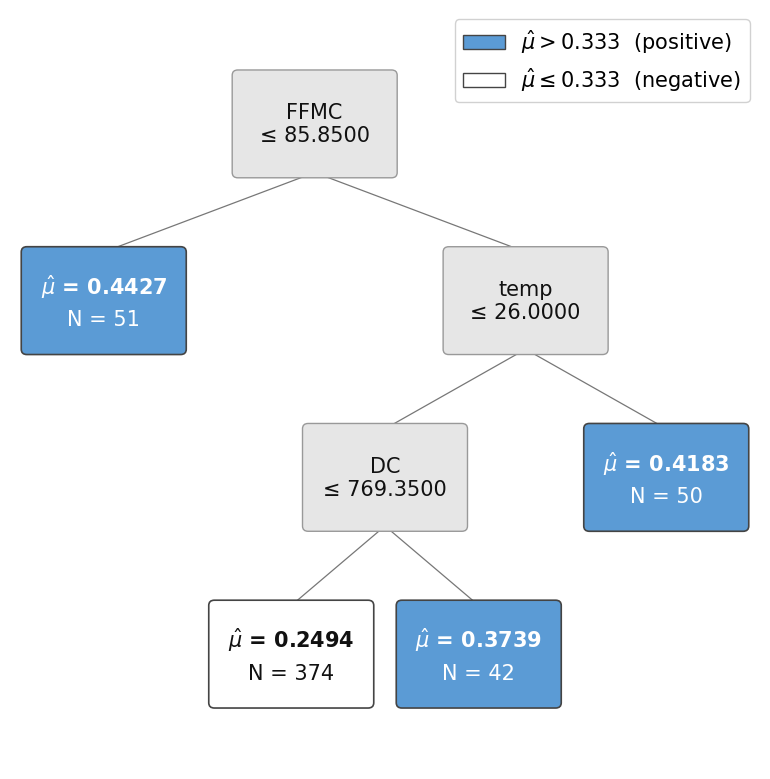

In [40]:
###### mdfs ######
model = targetree(depth=max_depth, minimum_portion=mp, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1, phat)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut, save_path=FIGURE_DIR / "forestfires_phat_mdfs.pdf", font_size=fs, split_rule_lines=split_lines)
plt.show()